# Sprint 5 — 16 Executive Report

Este notebook consolida los resultados finales del proyecto y genera el reporte ejecutivo para stakeholders.

Objetivo del Sprint 5: traducir el desempeño técnico del modelo a impacto económico, justificar el threshold operativo y dejar recomendaciones accionables para el Sprint 6.

**Decisión actual:** usar `LogisticRegression` tuneado con threshold operativo recomendado por valor económico.

## Lectura ejecutiva

El modelo final no debe evaluarse solo por recall, F2 o precision. Para decidir si conviene desplegarlo, se compara el impacto económico de distintos thresholds.

En la corrida actual, el threshold `0.50` tiene mayor recall, pero genera demasiados falsos positivos. Bajo los supuestos de negocio definidos, el threshold `0.70` maximiza el valor económico esperado porque reduce significativamente el rechazo de autos buenos, aun sacrificando parte del recall.

Este notebook no entrena modelos nuevos. Solo consolida resultados ya generados por:

- `12_ensembles_gradient_boosting.ipynb`
- `13_final_validation.ipynb`
- `14_business_value.ipynb`

In [1]:
from pathlib import Path
import sys
import textwrap
import warnings

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)

print("Proyecto:", PROJECT_ROOT)
print("Reports:", REPORTS_DIR)

Proyecto: /Users/alexandralozano/dp261-g1
Reports: /Users/alexandralozano/dp261-g1/reports


In [2]:
# Cargar artefactos generados por notebooks previos.

def read_report_csv(filename):
    path = REPORTS_DIR / filename
    if path.exists():
        df = pd.read_csv(path)
        print(f"Cargado: {path}")
        return df
    print(f"Pendiente: {path}. Ejecuta notebooks previos antes de este reporte.")
    return pd.DataFrame()

models_results = read_report_csv("models_results.csv")
final_validation_metrics = read_report_csv("final_validation_metrics.csv")
final_model_selection = read_report_csv("final_model_selection.csv")
threshold_business_value = read_report_csv("threshold_business_value.csv")
threshold_business_comparison = read_report_csv("threshold_business_value_comparison.csv")
business_impact = read_report_csv("business_confusion_matrix_impact.csv")
gain_curve = read_report_csv("gain_curve.csv")

Cargado: /Users/alexandralozano/dp261-g1/reports/models_results.csv
Cargado: /Users/alexandralozano/dp261-g1/reports/final_validation_metrics.csv
Cargado: /Users/alexandralozano/dp261-g1/reports/final_model_selection.csv
Cargado: /Users/alexandralozano/dp261-g1/reports/threshold_business_value.csv
Cargado: /Users/alexandralozano/dp261-g1/reports/threshold_business_value_comparison.csv
Cargado: /Users/alexandralozano/dp261-g1/reports/business_confusion_matrix_impact.csv
Cargado: /Users/alexandralozano/dp261-g1/reports/gain_curve.csv


In [3]:
# Tabla 1: comparación de modelos del Sprint 4.

model_cols = [
    c for c in [
        "source", "model",
        "recall_cv_mean", "f2_cv_mean", "precision_cv_mean",
        "f1_cv_mean", "roc_auc_cv_mean", "average_precision_cv_mean"
    ]
    if c in models_results.columns
]

if not models_results.empty:
    model_summary = (
        models_results[model_cols]
        .sort_values(["recall_cv_mean", "f2_cv_mean", "precision_cv_mean"], ascending=[False, False, False])
        .reset_index(drop=True)
    )
    display(model_summary)
else:
    model_summary = pd.DataFrame()

,source,model,recall_cv_mean,f2_cv_mean,precision_cv_mean,f1_cv_mean,roc_auc_cv_mean,average_precision_cv_mean
0,tuned_loaded,DecisionTree,0.613821,0.456661,0.228596,0.331660,0.718980,0.421301
1,tuned_loaded,LogisticRegression,0.610976,0.483195,0.263126,0.367824,0.754036,0.436023
2,tuned_loaded,LinearSVM,0.603252,0.481969,0.267182,0.370319,0.754027,0.430728
3,advanced_boosting,XGBoost,0.582520,0.482343,0.285934,0.383508,0.766292,0.477231
4,advanced_boosting,LightGBM,0.536585,0.468746,0.311559,0.394115,0.766080,0.479273
5,bagging,Bagging_DecisionTree,0.532520,0.465843,0.310670,0.392293,0.756702,0.468173
6,ensemble,Stacking_lr,0.232927,0.271256,0.795794,0.360189,0.756104,0.450171
7,ensemble,Voting_soft,NaN,NaN,NaN,NaN,NaN,NaN


### Interpretación de selección de modelo

La comparación de modelos muestra que `DecisionTree` alcanza un recall ligeramente superior, pero `LogisticRegression` tuneado ofrece un mejor equilibrio general: recall muy cercano, mayor F2 y mayor precision.

Por eso se mantiene `LogisticRegression` como modelo final: es competitivo en detección de `Bad Buys`, menos agresivo que un árbol individual y más interpretable para explicar la decisión ante stakeholders.

In [4]:
# Tabla 2: comparación entre threshold estándar 0.50 y threshold óptimo económico.

comparison_cols = [
    c for c in [
        "scenario", "threshold", "business_value", "avg_value_per_vehicle",
        "recall", "f2", "precision", "positive_rate",
        "tp", "fp", "fn", "tn",
        "tp_value", "fp_value", "fn_value", "tn_value"
    ]
    if c in threshold_business_comparison.columns
]

if not threshold_business_comparison.empty:
    threshold_summary = threshold_business_comparison[comparison_cols].copy()
    display(threshold_summary)
else:
    threshold_summary = pd.DataFrame()

,scenario,threshold,business_value,avg_value_per_vehicle,recall,f2,precision,positive_rate,tp,fp,fn,tn,tp_value,fp_value,fn_value,tn_value
0,operational_0_50,0.5,26500,1.815442,0.615599,0.487859,0.266586,0.283962,1105,3040,690,9762,2762500,-2736000,0,0
1,business_optimal,0.7,1079600,73.960403,0.367131,0.389020,0.510853,0.088374,659,631,1136,12171,1647500,-567900,0,0


In [5]:
# Tabla 3: matriz de confusión valorizada.

impact_cols = [
    c for c in [
        "scenario", "threshold", "confusion_cell",
        "count", "unit_value", "total_value", "business_meaning"
    ]
    if c in business_impact.columns
]

if not business_impact.empty:
    display(business_impact[impact_cols])
else:
    print("Pendiente matriz de impacto económico.")

,scenario,threshold,confusion_cell,count,unit_value,total_value,business_meaning
0,operational_0_50,0.5,TP_bad_buy_detected,1105,2500,2762500,Bad Buy detectado; se evita comprar una unidad...
1,operational_0_50,0.5,FP_good_buy_rejected,3040,-900,-2736000,Auto bueno marcado como malo; se pierde oportu...
2,operational_0_50,0.5,FN_bad_buy_missed,690,0,0,Bad Buy no detectado; se acepta una unidad rie...
3,operational_0_50,0.5,TN_good_buy_accepted,9762,0,0,Auto bueno aceptado; flujo normal de compra
4,business_optimal,0.7,TP_bad_buy_detected,659,2500,1647500,Bad Buy detectado; se evita comprar una unidad...
5,business_optimal,0.7,FP_good_buy_rejected,631,-900,-567900,Auto bueno marcado como malo; se pierde oportu...
6,business_optimal,0.7,FN_bad_buy_missed,1136,0,0,Bad Buy no detectado; se acepta una unidad rie...
7,business_optimal,0.7,TN_good_buy_accepted,12171,0,0,Auto bueno aceptado; flujo normal de compra


In [6]:
# KPIs ejecutivos de decisión.

def get_row(df, scenario):
    if df.empty or "scenario" not in df.columns:
        return None
    tmp = df[df["scenario"].eq(scenario)]
    return None if tmp.empty else tmp.iloc[0]

op = get_row(threshold_business_comparison, "operational_0_50")
best = get_row(threshold_business_comparison, "business_optimal")

if op is not None and best is not None:
    delta_value = best["business_value"] - op["business_value"]

    decision_summary = pd.DataFrame([{
        "decision": "GO controlado hacia Sprint 6",
        "model": "LogisticRegression tuneado",
        "technical_reference_threshold": op["threshold"],
        "recommended_business_threshold": best["threshold"],
        "business_value_reference": op["business_value"],
        "business_value_recommended": best["business_value"],
        "delta_business_value": delta_value,
        "recall_reference": op["recall"],
        "recall_recommended": best["recall"],
        "precision_reference": op["precision"],
        "precision_recommended": best["precision"],
        "positive_rate_reference": op["positive_rate"],
        "positive_rate_recommended": best["positive_rate"],
        "recommendation": "Usar el modelo como soporte a decisión y validar el threshold con negocio antes de automatizar rechazos."
    }])

    display(decision_summary)

    decision_path = REPORTS_DIR / "final_decision_summary.csv"
    decision_summary.to_csv(decision_path, index=False)
    print("Guardado:", decision_path)
else:
    decision_summary = pd.DataFrame()
    print("No se pudo construir el resumen de decisión. Revisa threshold_business_value_comparison.csv.")

,decision,model,technical_reference_threshold,recommended_business_threshold,business_value_reference,business_value_recommended,delta_business_value,recall_reference,recall_recommended,precision_reference,precision_recommended,positive_rate_reference,positive_rate_recommended,recommendation
0,GO controlado hacia Sprint 6,LogisticRegression tuneado,0.5,0.7,26500,1079600,1053100,0.615599,0.367131,0.266586,0.510853,0.283962,0.088374,Usar el modelo como soporte a decisión y valid...


Guardado: /Users/alexandralozano/dp261-g1/reports/final_decision_summary.csv


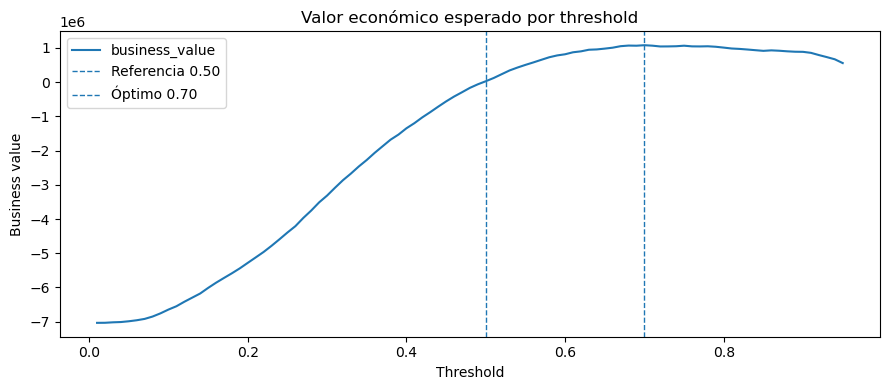

Guardado: /Users/alexandralozano/dp261-g1/reports/figures/business_value_by_threshold.png


In [7]:
# Gráfico: valor económico por threshold.

if not threshold_business_value.empty and {"threshold", "business_value"}.issubset(threshold_business_value.columns):
    fig_dir = REPORTS_DIR / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)

    plot_df = threshold_business_value.sort_values("threshold")

    ax = plot_df.plot(
        x="threshold",
        y="business_value",
        figsize=(9, 4),
        legend=False,
        title="Valor económico esperado por threshold"
    )
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Business value")
    ax.axvline(0.50, linestyle="--", linewidth=1, label="Referencia 0.50")
    if best is not None:
        ax.axvline(float(best["threshold"]), linestyle="--", linewidth=1, label=f"Óptimo {best['threshold']:.2f}")
    ax.legend()
    plt.tight_layout()

    fig_path = fig_dir / "business_value_by_threshold.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Guardado:", fig_path)

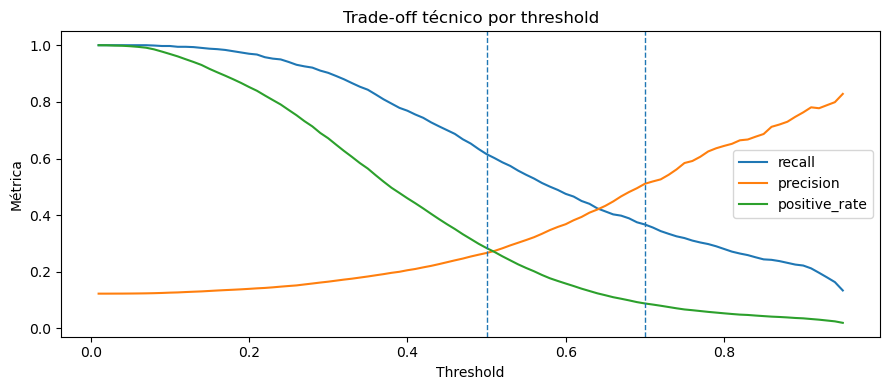

Guardado: /Users/alexandralozano/dp261-g1/reports/figures/threshold_tradeoff_metrics.png


In [8]:
# Gráfico: trade-off técnico entre recall, precision y positive rate.

if not threshold_business_value.empty:
    metric_cols = ["recall", "precision", "positive_rate"]
    available_metrics = [c for c in metric_cols if c in threshold_business_value.columns]

    if available_metrics:
        plot_df = threshold_business_value.sort_values("threshold")

        ax = plot_df.plot(
            x="threshold",
            y=available_metrics,
            figsize=(9, 4),
            title="Trade-off técnico por threshold"
        )
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Métrica")
        ax.axvline(0.50, linestyle="--", linewidth=1)
        if best is not None:
            ax.axvline(float(best["threshold"]), linestyle="--", linewidth=1)
        plt.tight_layout()

        fig_path = REPORTS_DIR / "figures" / "threshold_tradeoff_metrics.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show()

        print("Guardado:", fig_path)

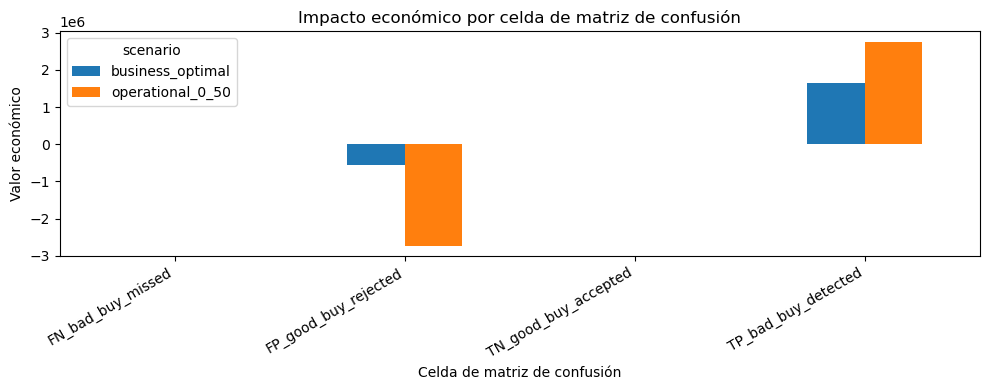

Guardado: /Users/alexandralozano/dp261-g1/reports/figures/confusion_matrix_business_impact.png


In [9]:
# Gráfico: impacto económico por celda de matriz de confusión.

if not business_impact.empty and {"scenario", "confusion_cell", "total_value"}.issubset(business_impact.columns):
    pivot_impact = (
        business_impact
        .pivot_table(index="confusion_cell", columns="scenario", values="total_value", aggfunc="sum")
        .fillna(0)
    )

    ax = pivot_impact.plot(
        kind="bar",
        figsize=(10, 4),
        title="Impacto económico por celda de matriz de confusión"
    )
    ax.set_xlabel("Celda de matriz de confusión")
    ax.set_ylabel("Valor económico")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    fig_path = REPORTS_DIR / "figures" / "confusion_matrix_business_impact.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Guardado:", fig_path)

## Recomendación ejecutiva

Se recomienda avanzar a Sprint 6 con un **MVP controlado** del modelo `LogisticRegression` tuneado, usando el threshold económico recomendado.

La recomendación no es automatizar rechazos de manera ciega. El uso inicial debería ser como **sistema de soporte a decisión**:

- autos con score alto: revisión prioritaria o rechazo bajo política definida;
- autos en zona intermedia: revisión manual o inspección adicional;
- autos con score bajo: flujo operativo regular.

Esto permite capturar valor económico sin bloquear excesivamente oportunidades comerciales.

In [10]:
# Construir texto ejecutivo dinámico para exportar a Markdown.

def money(x):
    if pd.isna(x):
        return "N/A"
    return f"{x:,.0f}"

def pct(x):
    if pd.isna(x):
        return "N/A"
    return f"{x:.1%}"

def num(x):
    if pd.isna(x):
        return "N/A"
    return f"{x:,.0f}"

if op is not None and best is not None:
    executive_text = f"""
# Reporte ejecutivo — Predicción de Bad Buys

## 1. Resumen ejecutivo

El proyecto desarrolló un modelo para anticipar vehículos con alto riesgo de convertirse en `Bad Buy` en subastas automotrices. El objetivo de negocio es reducir compras riesgosas sin bloquear de forma excesiva el flujo de autos buenos que sostienen las ventas.

El modelo seleccionado es **LogisticRegression tuneado**. Esta alternativa fue elegida porque mantiene un recall competitivo frente a otros modelos, pero ofrece mejor balance operativo en F2, precision e interpretabilidad.

La evaluación económica muestra que el threshold estándar `0.50` no maximiza el valor esperado. Bajo los supuestos definidos, el threshold óptimo económico es **{best["threshold"]:.2f}**.

## 2. Decisión recomendada

| Elemento | Recomendación |
|---|---|
| Modelo final | LogisticRegression tuneado |
| Threshold técnico de referencia | {op["threshold"]:.2f} |
| Threshold operativo recomendado | {best["threshold"]:.2f} |
| Criterio final | Maximizar valor económico esperado |
| Modo de uso inicial | Soporte a decisión / piloto controlado |
| Decisión Sprint 6 | GO controlado hacia MVP |

## 3. Evidencia técnica

Con threshold `0.50`, el modelo detecta más Bad Buys, pero también rechaza demasiados autos buenos:

- Recall: **{pct(op["recall"])}**
- Precision: **{pct(op["precision"])}**
- Positive rate: **{pct(op["positive_rate"])}**
- TP: **{num(op["tp"])}**
- FP: **{num(op["fp"])}**
- FN: **{num(op["fn"])}**
- TN: **{num(op["tn"])}**

Con threshold `{best["threshold"]:.2f}`, el modelo es más conservador y rentable:

- Recall: **{pct(best["recall"])}**
- Precision: **{pct(best["precision"])}**
- Positive rate: **{pct(best["positive_rate"])}**
- TP: **{num(best["tp"])}**
- FP: **{num(best["fp"])}**
- FN: **{num(best["fn"])}**
- TN: **{num(best["tn"])}**

## 4. Impacto económico

El análisis costo–beneficio considera:

- TP: ahorro por detectar y evitar un Bad Buy.
- FP: margen perdido por rechazar un auto bueno.
- FN: sin valor incremental frente a operar sin modelo.
- TN: flujo normal de operación.

Comparación principal:

| Escenario | Threshold | Business value | Valor promedio por vehículo |
|---|---:|---:|---:|
| Referencia técnica | {op["threshold"]:.2f} | {money(op["business_value"])} | {op["avg_value_per_vehicle"]:.2f} |
| Óptimo económico | {best["threshold"]:.2f} | {money(best["business_value"])} | {best["avg_value_per_vehicle"]:.2f} |

El cambio de threshold genera una mejora estimada de **{money(best["business_value"] - op["business_value"])}** en valor económico respecto al threshold `0.50`.

## 5. Riesgos y limitaciones

1. **Dependencia de supuestos económicos.** El threshold recomendado depende de los valores asignados a TP, FP, FN y TN. Estos supuestos deben ser validados con negocio.
2. **Falsos negativos persistentes.** El threshold económico reduce falsos positivos, pero deja pasar más Bad Buys que el threshold 0.50. Por eso se recomienda uso como soporte a decisión y no automatización total.
3. **Drift de datos.** Cambios en precios, subastas, garantías o mix de vehículos pueden degradar el modelo.
4. **Generalización.** El modelo fue entrenado con datos históricos; debe monitorearse contra datos nuevos.
5. **Interpretabilidad.** LogisticRegression facilita explicación general, pero en producción se recomienda incluir explicabilidad por instancia en dashboard.

## 6. Recomendaciones accionables

- Desplegar el modelo en Sprint 6 como MVP controlado.
- Usar threshold `{best["threshold"]:.2f}` como umbral operativo inicial.
- Mantener threshold `0.50` como referencia de cobertura de riesgo para análisis comparativo, no como decisión final automática.
- Implementar monitoreo mensual de recall, precision, positive rate y business value.
- Revisar la matriz costo–beneficio con el sponsor antes de automatizar rechazos.
- Incorporar dashboard con KPIs, matriz de confusión, curva de ganancia y explicación de predicciones.
- Definir un proceso de revisión manual para casos de riesgo intermedio.

## 7. Handoff para Sprint 6

Artefactos que deben quedar disponibles:

- `models/final_model.pkl`
- `reports/final_decision_summary.csv`
- `reports/threshold_business_value.csv`
- `reports/threshold_business_value_comparison.csv`
- `reports/business_confusion_matrix_impact.csv`
- `reports/executive_report.md`
- `dashboard/app.py`
- contrato de entrada/salida para API o dashboard
- definición del threshold operativo y supuestos económicos

## 8. Conclusión

El modelo genera valor cuando el threshold se define como una decisión de negocio y no solo técnica. La recomendación final es avanzar con `LogisticRegression` tuneado y threshold `{best["threshold"]:.2f}` porque maximiza el valor económico esperado bajo los supuestos actuales, reduciendo de forma importante los falsos positivos y manteniendo una detección relevante de Bad Buys.
""".strip()
else:
    executive_text = """
# Reporte ejecutivo — Predicción de Bad Buys

Pendiente de resultados. Ejecutar primero `13_final_validation.ipynb` y `14_business_value.ipynb`.
""".strip()

print(executive_text[:2000])

# Reporte ejecutivo — Predicción de Bad Buys

## 1. Resumen ejecutivo

El proyecto desarrolló un modelo para anticipar vehículos con alto riesgo de convertirse en `Bad Buy` en subastas automotrices. El objetivo de negocio es reducir compras riesgosas sin bloquear de forma excesiva el flujo de autos buenos que sostienen las ventas.

El modelo seleccionado es **LogisticRegression tuneado**. Esta alternativa fue elegida porque mantiene un recall competitivo frente a otros modelos, pero ofrece mejor balance operativo en F2, precision e interpretabilidad.

La evaluación económica muestra que el threshold estándar `0.50` no maximiza el valor esperado. Bajo los supuestos definidos, el threshold óptimo económico es **0.70**.

## 2. Decisión recomendada

| Elemento | Recomendación |
|---|---|
| Modelo final | LogisticRegression tuneado |
| Threshold técnico de referencia | 0.50 |
| Threshold operativo recomendado | 0.70 |
| Criterio final | Maximizar valor económico esperado |
| Modo de uso ini

In [11]:
# Guardar reporte ejecutivo y recomendaciones.

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

executive_report_path = REPORTS_DIR / "executive_report.md"
recommendations_path = REPORTS_DIR / "recommendations.md"

executive_report_path.write_text(executive_text, encoding="utf-8")

recommendations_text = """
# Recomendaciones finales

1. Avanzar a Sprint 6 con un MVP controlado del modelo final.
2. Usar LogisticRegression tuneado como modelo base por balance entre desempeño, estabilidad e interpretabilidad.
3. Adoptar el threshold económico recomendado como umbral operativo inicial.
4. No automatizar rechazos sin validación de negocio; usar el modelo como soporte a decisión.
5. Monitorear mensualmente recall, precision, positive rate, business value y drift.
6. Validar supuestos económicos con sponsor antes de producción.
7. Preparar handoff técnico con modelo, preprocessing, contratos de datos y dashboard.
""".strip()

recommendations_path.write_text(recommendations_text, encoding="utf-8")

print("Guardado:", executive_report_path)
print("Guardado:", recommendations_path)

Guardado: /Users/alexandralozano/dp261-g1/reports/executive_report.md
Guardado: /Users/alexandralozano/dp261-g1/reports/recommendations.md


## Cierre

El entregable final cumple el enfoque del Sprint 5: convierte métricas técnicas en una recomendación de negocio, documenta el threshold operativo, explicita riesgos y deja el handoff necesario para iniciar Sprint 6.